# HaGRID Gesture Classifier

Layer 3b of the vision pipeline. 18 classes, 64x64 hand crops, from-scratch CNN.

In [1]:
import os, json, math, random, hashlib
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score

In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"device: {device}")

device: mps


In [3]:
DATA_ROOT = "training data/hagrid-sample-30k-384p"
ANN_DIR   = f"{DATA_ROOT}/ann_train_val"
IMG_ROOT  = f"{DATA_ROOT}/hagrid_30k"
IMG_DIR_PREFIX = "train_val_"

CLASS_NAMES = [
    "call", "dislike", "fist", "four", "like", "mute", "ok", "one",
    "palm", "peace", "peace_inverted", "rock", "stop", "stop_inverted",
    "three", "three2", "two_up", "two_up_inverted",
]
NUM_CLASSES = 18
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
IMG_SIZE = 64

CKPT_DIR = "checkpoints"
CKPT_PATH = f"{CKPT_DIR}/gesture_classifier_best.pt"

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

assert len(CLASS_NAMES) == NUM_CLASSES
assert Path(ANN_DIR).is_dir(), f"missing {ANN_DIR} — is the working directory HAND_JOB?"
assert Path(IMG_ROOT).is_dir(), f"missing {IMG_ROOT}"
print("config ok")

config ok


In [4]:
def build_index():
    """Returns list of (img_path: str, bbox_xywh_norm: tuple, label_idx: int, user_id: str)."""
    rows = []
    dropped_no_gesture = 0
    dropped_missing_file = 0
    for cls in CLASS_NAMES:
        ann_path = Path(ANN_DIR) / f"{cls}.json"
        img_dir  = Path(IMG_ROOT) / f"{IMG_DIR_PREFIX}{cls}"
        with open(ann_path) as f:
            data = json.load(f)
        for image_id, meta in data.items():
            img_path = img_dir / f"{image_id}.jpg"
            if not img_path.is_file():
                dropped_missing_file += 1
                continue
            for bbox, label in zip(meta["bboxes"], meta["labels"]):
                if label == "no_gesture":
                    dropped_no_gesture += 1
                    continue
                if label not in CLASS_TO_IDX:
                    # stray label we do not know about — skip
                    continue
                rows.append((str(img_path), tuple(bbox), CLASS_TO_IDX[label], meta["user_id"]))
    print(f"rows: {len(rows)} | dropped no_gesture: {dropped_no_gesture} | dropped missing_file: {dropped_missing_file}")
    return rows

rows = build_index()

rows: 31832 | dropped no_gesture: 7052 | dropped missing_file: 477490


In [5]:
label_counts = Counter(r[2] for r in rows)
for i, c in enumerate(CLASS_NAMES):
    print(f"  {c:18s} {label_counts[i]:>5}")
print(f"total: {sum(label_counts.values())}")

  call                1763
  dislike             1783
  fist                1734
  four                1805
  like                1732
  mute                1811
  ok                  1750
  one                 1778
  palm                1770
  peace               1769
  peace_inverted      1742
  rock                1736
  stop                1748
  stop_inverted       1803
  three               1751
  three2              1737
  two_up              1855
  two_up_inverted     1765
total: 31832


In [6]:
def user_split(rows, train_pct=0.8, val_pct=0.1, seed=SEED):
    """Group by user_id. Deterministic assignment via hash+seed."""
    user_ids = sorted({r[3] for r in rows})
    rng = random.Random(seed)
    rng.shuffle(user_ids)
    n = len(user_ids)
    n_train = int(n * train_pct)
    n_val   = int(n * val_pct)
    train_users = set(user_ids[:n_train])
    val_users   = set(user_ids[n_train:n_train + n_val])
    test_users  = set(user_ids[n_train + n_val:])

    train = [r for r in rows if r[3] in train_users]
    val   = [r for r in rows if r[3] in val_users]
    test  = [r for r in rows if r[3] in test_users]

    # sanity
    assert train_users.isdisjoint(val_users)
    assert train_users.isdisjoint(test_users)
    assert val_users.isdisjoint(test_users)
    return train, val, test, (train_users, val_users, test_users)

train_rows, val_rows, test_rows, (train_u, val_u, test_u) = user_split(rows)
print(f"users  train/val/test: {len(train_u)} / {len(val_u)} / {len(test_u)}")
print(f"rows   train/val/test: {len(train_rows)} / {len(val_rows)} / {len(test_rows)}")

users  train/val/test: 6377 / 797 / 798
rows   train/val/test: 25309 / 3457 / 3066


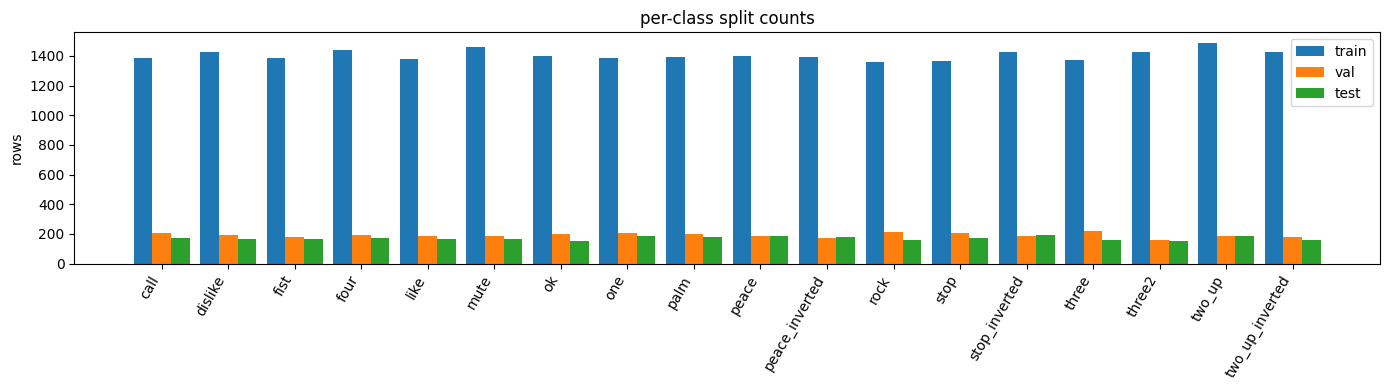

In [7]:
def split_class_counts(split_rows):
    c = Counter(r[2] for r in split_rows)
    return [c[i] for i in range(NUM_CLASSES)]

tr_c = split_class_counts(train_rows)
va_c = split_class_counts(val_rows)
te_c = split_class_counts(test_rows)

x = np.arange(NUM_CLASSES)
w = 0.28
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(x - w, tr_c, w, label="train")
ax.bar(x,     va_c, w, label="val")
ax.bar(x + w, te_c, w, label="test")
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=60, ha="right")
ax.set_ylabel("rows"); ax.legend(); ax.set_title("per-class split counts")
plt.tight_layout(); plt.show()

for i, c in enumerate(CLASS_NAMES):
    if va_c[i] < 50 or te_c[i] < 50:
        print(f"WARN: {c} has low eval count (val={va_c[i]}, test={te_c[i]})")